In [100]:
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, precision_recall_curve,
    classification_report, confusion_matrix, accuracy_score
)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from joblib import dump, load


In [2]:
DATA_CSV   = "../data/processed/vk_tg_balanced.csv"     # сбалансированный датасет


MODELS_DIR = Path("../models")
SBERT_DIR  = MODELS_DIR / "sbert"
SBERT_NPY  = SBERT_DIR / "embeddings_sbert_large_nlu_ru.npy"
SBERT_META = SBERT_DIR / "embeddings_sbert_large_nlu_ru.json"
SBERT_TXT  = SBERT_DIR / "texts.txt"                    # опционально: сохраним тексты для контроля
MODELS_DIR.mkdir(parents=True, exist_ok=True)
SBERT_DIR.mkdir(parents=True, exist_ok=True)


df = pd.read_csv(DATA_CSV)

print(f"датасет: {df.shape}")

датасет: (3708, 107)


In [3]:
# Остальные оставить строками (object)
df['image_url'] = df['image_url'].astype(str)
df['tg_channel_username'] = df['tg_channel_username'].astype(str)
df['tg_fwd_src_name'] = df['tg_fwd_src_name'].astype(str)

# Преобразование типов bool - оставаем без изменений
df['is_ad'] = df['is_ad'].map({'True': True, 'False': False, True: True, False: False}).fillna(False).astype(bool)
df['tg_is_forwarded'] = df['tg_is_forwarded'].map({'True': True, 'False': False, True: True, False: False}).fillna(False).astype(bool)

C:\Users\user\AppData\Local\Temp\ipykernel_10836\4229482683.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['is_ad'] = df['is_ad'].map({'True': True, 'False': False, True: True, False: False}).fillna(False).astype(bool)
C:\Users\user\AppData\Local\Temp\ipykernel_10836\4229482683.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['tg_is_forwarded'] = df['tg_is_forwarded'].map({'True': True, 'False': False, True: True, False: False}).fillna(False).astype(bool)


In [101]:
# functions for logging and threshold

def tune_threshold(y_true, y_proba):
    """Подбираем порог по максимуму F1 по PR-кривой (на данном сете).
    Идеальнее тюнить на валидации, а не на тесте.
    """
    p, r, thr = precision_recall_curve(y_true, y_proba)
    f1s = 2*p*r/(p+r+1e-9)
    i = int(np.nanargmax(f1s))
    return (0.5 if i>=len(thr) else float(thr[max(i-1,0)]))


results = []

def log_and_append(name, y_true, y_proba, results, digits=3, print_report=True):
    """Считает AUC/PR-AUC, подбирает порог, печатает classification_report
       и добавляет всё в results (в т.ч. report и confusion matrix).
    """
    thr = tune_threshold(y_true, y_proba)
    y_pred = (y_proba >= thr).astype(int)

    roc = roc_auc_score(y_true, y_proba)
    prc = average_precision_score(y_true, y_proba)
    f1b = f1_score(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    rpt_txt  = classification_report(y_true, y_pred, digits=digits)
    rpt_dict = classification_report(y_true, y_pred, digits=digits, output_dict=True)
    cm = confusion_matrix(y_true, y_pred).tolist()

    rec = {
        "name": name,
        "roc_auc": roc,
        "pr_auc":  prc,
        "f1@best": f1b,
        "accuracy": acc,
        "thr": thr,
        "report": rpt_dict,
        "cm": cm
    }
    results.append(rec)

    print(f"{name}: ROC-AUC={roc:.4f}  PR-AUC={prc:.4f}  F1@{thr:.3f}={f1b:.4f}  ACC={acc:.4f}")
    if print_report:
        print("\nclassification_report:\n" + rpt_txt)
        print("confusion_matrix [[tn, fp],[fn, tp]]:", cm)

Load embeddings make train test split, identify y

In [11]:
# Load embeddings from file
X_sbert = np.load(SBERT_NPY) 
print("df:", df.shape, "| X_sbert:", X_sbert.shape)

y = df['is_viral'].astype(int).values

# train test split
X_train_idx, X_test_idx, y_train, y_test = train_test_split(
    np.arange(len(df)), y, test_size=0.2, stratify=y, random_state=42
)

Xtr_sbert = X_sbert[X_train_idx]
Xte_sbert = X_sbert[X_test_idx]

df: (3708, 107) | X_sbert: (3708, 1024)


TF_IDF + LOG REGRESSION - BASELINE

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from joblib import dump
from sklearn.metrics import classification_report, roc_auc_score



y = df['is_viral'].astype(int).values

# Создаем массив индексов для полного датасета
all_indices = np.arange(len(df))

# Стратифицированное разбиение индексов
X_train_idx, X_test_idx, y_train, y_test = train_test_split(
    all_indices, y, stratify=y, test_size=0.2, random_state=42
)

# тот же df, y_train/y_test, X_train_idx/X_test_idx уже есть
PREFERRED = ["lemma_text", "clean_text", "text"]
tfidf_col = next((c for c in PREFERRED if c in df.columns), None)
assert tfidf_col is not None, "Нет текстового столбца для TF-IDF"

Xtr_text = df.loc[X_train_idx, tfidf_col].fillna("").astype(str)
Xte_text = df.loc[X_test_idx,  tfidf_col].fillna("").astype(str)

vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2), min_df=3)
Xtr_tfidf = vectorizer.fit_transform(Xtr_text)
Xte_tfidf = vectorizer.transform(Xte_text)
dump(vectorizer, MODELS_DIR / "tfidf_vectorizer.joblib")

clf_tfidf = LogisticRegression(max_iter=2000, class_weight="balanced", n_jobs=-1)
clf_tfidf.fit(Xtr_tfidf, y_train)
dump(clf_tfidf, MODELS_DIR / "tfidf_lr.joblib")

proba = clf_tfidf.predict_proba(Xte_tfidf)[:,1]
log_and_append("tfidf_lr", y_test, proba, results)

tfidf_lr: ROC-AUC=0.7259  PR-AUC=0.7200  F1@0.397=0.7146  ACC=0.6361

classification_report:
              precision    recall  f1-score   support

           0      0.802     0.361     0.498       371
           1      0.588     0.911     0.715       371

    accuracy                          0.636       742
   macro avg      0.695     0.636     0.606       742
weighted avg      0.695     0.636     0.606       742

confusion_matrix [[tn, fp],[fn, tp]]: [[134, 237], [33, 338]]


SBERT embeddings  + LogisticRegression

In [ ]:
from pathlib import Path

MODELS_DIR = Path(MODELS_DIR) if isinstance(MODELS_DIR, str) else MODELS_DIR
MODELS_DIR.mkdir(parents=True, exist_ok=True)



results = []

clf_sbert = LogisticRegression(max_iter=2000, class_weight="balanced", n_jobs=-1)
clf_sbert.fit(Xtr_sbert, y_train)
dump(clf_sbert, MODELS_DIR / "sbert_lr.joblib")

proba = clf_sbert.predict_proba(Xte_sbert)[:,1]
log_and_append("sbert_lr", y_test, proba, results)

sbert_lr: ROC-AUC=0.7484  PR-AUC=0.7201  F1@0.358=0.7380  ACC=0.6833

classification_report:
              precision    recall  f1-score   support

           0      0.815     0.474     0.600       371
           1      0.629     0.892     0.738       371

    accuracy                          0.683       742
   macro avg      0.722     0.683     0.669       742
weighted avg      0.722     0.683     0.669       742

confusion_matrix [[tn, fp],[fn, tp]]: [[176, 195], [40, 331]]


SVM (RBF) on SBERT-embeddings

In [12]:
from sklearn.svm import SVC

# Load embeddings from file
X_sbert = np.load(SBERT_NPY) 
print("df:", df.shape, "| X_sbert:", X_sbert.shape)

sbert_svm = SVC(kernel="rbf", C=2.0, gamma="scale", class_weight=None, probability=True, random_state=42)
sbert_svm.fit(Xtr_sbert, y_train)
dump(sbert_svm, MODELS_DIR / "sbert_svm_rbf.joblib")

proba = sbert_svm.predict_proba(Xte_sbert)[:,1]
log_and_append("sbert_svm_rbf", y_test, proba, results)

df: (3708, 107) | X_sbert: (3708, 1024)
sbert_svm_rbf: ROC-AUC=0.7943  PR-AUC=0.7655  F1@0.398=0.7584  ACC=0.7372

classification_report:
              precision    recall  f1-score   support

           0      0.788     0.650     0.712       371
           1      0.702     0.825     0.758       371

    accuracy                          0.737       742
   macro avg      0.745     0.737     0.735       742
weighted avg      0.745     0.737     0.735       742

confusion_matrix [[tn, fp],[fn, tp]]: [[241, 130], [65, 306]]


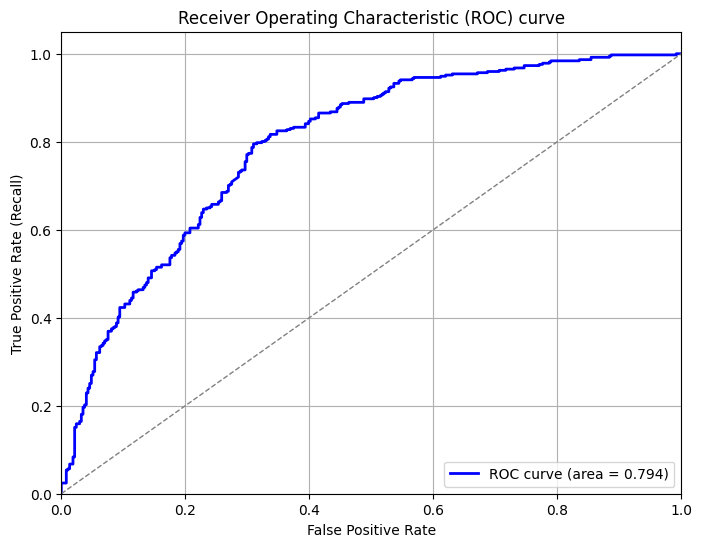

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# y_test — истинные метки (0/1)
# proba — вероятности положительного класса из модели

fpr, tpr, thresholds = roc_curve(y_test, proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


MLP on SBERT

In [28]:
from sklearn.neural_network import MLPClassifier

sbert_mlp = MLPClassifier(hidden_layer_sizes=(256,64),
                          activation="relu",
                          alpha=1e-4,
                          learning_rate_init=1e-3,
                          batch_size=128,
                          max_iter=80,
                          early_stopping=True,
                          random_state=42)
sbert_mlp.fit(Xtr_sbert, y_train)
dump(sbert_mlp, MODELS_DIR / "sbert_mlp.joblib")

proba = sbert_mlp.predict_proba(Xte_sbert)[:,1]
log_and_append("sbert_mlp", y_test, proba, results)

sbert_mlp: ROC-AUC=0.7799  PR-AUC=0.7543  F1@0.238=0.7486  ACC=0.7022

classification_report:
              precision    recall  f1-score   support

           0      0.821     0.518     0.635       371
           1      0.648     0.887     0.749       371

    accuracy                          0.702       742
   macro avg      0.734     0.702     0.692       742
weighted avg      0.734     0.702     0.692       742

confusion_matrix [[tn, fp],[fn, tp]]: [[192, 179], [42, 329]]


In [14]:
# additional features 
# time of publication as a cycle

import numpy as np
df["hour_sin"] = np.sin(2*np.pi*df["hour_posted"]/24)
df["hour_cos"] = np.cos(2*np.pi*df["hour_posted"]/24)
df["dow_sin"]  = np.sin(2*np.pi*df["dow_posted"]/7)
df["dow_cos"]  = np.cos(2*np.pi*df["dow_posted"]/7)

In [15]:
# content structure
import re
t = df["text"].fillna("").astype(str)
df["num_sentences"] = t.str.count(r"[.!?]")
df["num_exclaims"]  = t.str.count(r"!")
df["num_questions"] = t.str.count(r"\?")
df["caps_ratio"]    = t.apply(lambda s: sum(ch.isupper() for ch in s)/max(len(s),1))
df["digit_ratio"]   = t.apply(lambda s: sum(ch.isdigit() for ch in s)/max(len(s),1))
df["url_count"]     = t.str.count(r"https?://")

In [16]:
df.to_csv(DATA_CSV, index=False)

SBERT + BiGRU + Self-Attention + Metadata (freeze encoder)

In [ ]:
# ==== SBERT + BiGRU + Self-Attn + Metadata ====
import sys, subprocess, importlib, numpy as np, torch, json
from pathlib import Path

# deps
try:
    import transformers
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "transformers"])
    importlib.invalidate_caches()
    import transformers

from transformers import AutoTokenizer, AutoModel
from torch import nn
from torch.utils.data import Dataset, DataLoader

# настройки
TEXT_COL = "clean_text" if "clean_text" in df.columns else ("text" if "text" in df.columns else "lemma_text")
ENCODER_NAME_CANDS = [
    # "ai-forever/sbert_large_mt_nlu_ru",     # может не влезть в RAM/GPU
    "cointegrated/rubert-tiny2"             # лёгкий фолбэк
]
MAX_LEN = 256
BATCH  = 8 if torch.cuda.is_available() else 12  # экономно на CPU
EPOCHS = 3
LR     = 2e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# выбрать энкодер с фолбэком
tok = mdl = None
last_err = None
for name in ENCODER_NAME_CANDS:
    try:
        tok = AutoTokenizer.from_pretrained(name)
        mdl = AutoModel.from_pretrained(name)
        print("Encoder:", name)
        ENCODER_USED = name
        break
    except Exception as e:
        print("❌", name, e); last_err = e
if mdl is None: raise last_err

# фризим encoder
for p in mdl.parameters():
    p.requires_grad_(False)
mdl.to(DEVICE)
mdl.eval()

# данные
class TokMetaDS(Dataset):
    def __init__(self, frame, idx, tokenizer, text_col, num_cols, max_len, y):
        self.frame, self.idx = frame, np.array(idx)
        self.tokenizer, self.text_col = tokenizer, text_col
        self.num_cols, self.max_len = num_cols, max_len
        self.y = y
        self.Xm = frame[num_cols].fillna(0).astype(np.float32).values

    def __len__(self): return len(self.idx)

    def __getitem__(self, i):
        j = self.idx[i]
        text = str(self.frame.iloc[j][self.text_col])
        enc = self.tokenizer(
            text, max_length=self.max_len, truncation=True, padding="max_length", return_tensors="pt"
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}  # input_ids, attention_mask, (token_type_ids)
        item["meta"] = torch.from_numpy(self.Xm[j])
        item["label"] = torch.tensor(int(self.y[j]), dtype=torch.long)
        return item

# модель: encoder(frozen) -> BiGRU -> Multihead Self-Attn -> pooled -> concat Meta_MLP -> Clf
class BiGRUAttnMeta(nn.Module):
    def __init__(self, encoder, meta_dim, gru_h=128, attn_heads=4, mlp_mid=64, p_drop=0.2):
        super().__init__()
        self.encoder = encoder
        # определим скрытую размерность энкодера
        with torch.no_grad():
            dummy = { "input_ids": torch.ones(1,8, dtype=torch.long),
                      "attention_mask": torch.ones(1,8, dtype=torch.long) }
            if "token_type_ids" in self.encoder.forward.__code__.co_varnames:
                dummy["token_type_ids"] = torch.zeros(1,8, dtype=torch.long)
            hdim = self.encoder(**dummy).last_hidden_state.shape[-1]
        self.bigru = nn.GRU(input_size=hdim, hidden_size=gru_h, batch_first=True, bidirectional=True)
        self.attn  = nn.MultiheadAttention(embed_dim=2*gru_h, num_heads=min(attn_heads, 2*gru_h//32), batch_first=True)
        self.proj_meta = nn.Sequential(
            nn.Linear(meta_dim, mlp_mid), nn.ReLU(), nn.Dropout(p_drop)
        ) if meta_dim>0 else None
        clf_in = (2*gru_h) + (mlp_mid if meta_dim>0 else 0)
        self.clf = nn.Sequential(
            nn.Linear(clf_in, 128), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(128, 1)
        )

    def forward(self, input_ids, attention_mask, meta=None, token_type_ids=None):
        with torch.no_grad():
            enc_out = self.encoder(input_ids=input_ids, attention_mask=attention_mask,
                                   token_type_ids=token_type_ids if token_type_ids is not None else None)
            x = enc_out.last_hidden_state  # (B,L,H)
        x,_ = self.bigru(x)                # (B,L,2H)
        x,_ = self.attn(x, x, x)           # self-attn
        x = x.mean(1)                      # mean-pool
        if self.proj_meta is not None and meta is not None:
            m = self.proj_meta(meta)
            x = torch.cat([x, m], dim=1)
        return self.clf(x).squeeze(1)

# лоадеры
tr_ds = TokMetaDS(df, X_train_idx, tok, TEXT_COL, num_cols, MAX_LEN, df[target_col].values)
te_ds = TokMetaDS(df, X_test_idx,  tok, TEXT_COL, num_cols, MAX_LEN, df[target_col].values)
tr_dl = DataLoader(tr_ds, batch_size=BATCH, shuffle=True,  num_workers=0)
te_dl = DataLoader(te_ds, batch_size=BATCH, shuffle=False, num_workers=0)

model = BiGRUAttnMeta(mdl, meta_dim=len(num_cols), gru_h=128, attn_heads=4, mlp_mid=64, p_drop=0.2).to(DEVICE)
opt = torch.optim.AdamW(model.parameters(), lr=LR)
loss_fn = nn.BCEWithLogitsLoss()

def predict_proba(dl):
    model.eval(); out=[]
    with torch.no_grad():
        for batch in dl:
            ids = batch["input_ids"].to(DEVICE)
            msk = batch["attention_mask"].to(DEVICE)
            tti = batch.get("token_type_ids")
            if tti is not None: tti = tti.to(DEVICE)
            meta = batch["meta"].to(DEVICE)
            logits = model(ids, msk, meta, tti)
            out.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(out)

best_val = 0.0
for ep in range(1, EPOCHS+1):
    model.train()
    for batch in tr_dl:
        ids = batch["input_ids"].to(DEVICE)
        msk = batch["attention_mask"].to(DEVICE)
        tti = batch.get("token_type_ids")
        if tti is not None: tti = tti.to(DEVICE)
        meta = batch["meta"].to(DEVICE)
        yb = batch["label"].float().to(DEVICE)
        logits = model(ids, msk, meta, tti)
        loss = loss_fn(logits, yb)
        opt.zero_grad(); loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
    # простая валидация
    proba = predict_proba(te_dl)
    from sklearn.metrics import average_precision_score
    pr = average_precision_score(y_test, proba)
    print(f"EP{ep}: PR-AUC={pr:.4f}")
    if pr > best_val: best_val = pr; torch.save(
        {"state_dict": model.state_dict(), "encoder": ENCODER_USED, "text_col": TEXT_COL,
         "num_cols": num_cols, "max_len": MAX_LEN}, Path(MODELS_DIR)/"neural_bgru_attn_meta.pt")

# итог
proba = predict_proba(te_dl)
log_and_append("neural_biGRU_attn+meta", y_test, proba, results)


Encoder: cointegrated/rubert-tiny2
EP1: PR-AUC=0.7558
EP2: PR-AUC=0.7169
EP3: PR-AUC=0.7579
neural_biGRU_attn+meta: ROC-AUC=0.8098  PR-AUC=0.7579  F1@0.345=0.7690  ACC=0.7709

classification_report:
              precision    recall  f1-score   support

           0      0.767     0.779     0.773       371
           1      0.775     0.763     0.769       371

    accuracy                          0.771       742
   macro avg      0.771     0.771     0.771       742
weighted avg      0.771     0.771     0.771       742

confusion_matrix [[tn, fp],[fn, tp]]: [[289, 82], [88, 283]]


SBERT Embeddings + CatBoost (metadata)

In [66]:
import re
import numpy as np
import pandas as pd
from pathlib import Path
from joblib import dump
from sklearn.model_selection import StratifiedShuffleSplit
from catboost import CatBoostClassifier, Pool

# Колонки для исключения
BASE_EXCLUDE = {
    "is_viral", "text", "log_followers","clean_text", "lemma_text",
    "platform", "source_name", "source_link", "image_url", "link",
    "post_id", "vk_group_id", "vk_from_id", "followers", "text_len",
    "tg_channel_id", "tg_channel_username", "tg_fwd_src_id", "tg_fwd_src_msg_id",
    "published_at", "published_at_local", "published_at_dt", "collected_at",
    "engagement_rate", "er_final", "tg_fwd_src_name", "reposts"
}

SENTIMENT_BAD = {
    "sentiment_label2", "neg_prob", "neu_prob", "pos_prob", "sentiment_score2",
}

DATE_SUFFIXES = ("2025-06-07", "2025-08-15")
FUTURE_SNAPSHOT_COLS = {c for c in df.columns if any(c.endswith(suf) for suf in DATE_SUFFIXES)}

exclude = set(BASE_EXCLUDE) | SENTIMENT_BAD | FUTURE_SNAPSHOT_COLS

num_cols = [
    c for c in df.columns
    if c not in exclude and (pd.api.types.is_numeric_dtype(df[c]) or df[c].dtype == "bool")
]

LEAKY_PATTERNS = [
    r'^(reposts)($|_pf|_\d{4}-\d{2}-\d{2})$', 
    r'^(er(_.*)?|engagement_.*)$',
]
LEAKY_RE = re.compile("|".join(LEAKY_PATTERNS), re.IGNORECASE)
leaky_cols = {c for c in num_cols if LEAKY_RE.match(c)}
num_cols = [c for c in num_cols if c not in leaky_cols]


X_tab = df[num_cols].fillna(0).astype(np.float32).values
Xtr_tab = X_tab[X_train_idx]
Xte_tab = X_tab[X_test_idx]

# SBERT эмбеддинги как numpy масссивы, должны быть предварительно рассчитаны
Xtr_sbert = X_sbert[X_train_idx]
Xte_sbert = X_sbert[X_test_idx]

# Объединяем признаки
Xtr_f = np.hstack([Xtr_sbert, Xtr_tab])
Xte_f = np.hstack([Xte_sbert, Xte_tab])

# Валидационный сплит
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
tr_idx, val_idx = next(sss.split(Xtr_f, y_train))
X_train_pool = Pool(Xtr_f[tr_idx], label=y_train[tr_idx])
X_val_pool = Pool(Xtr_f[val_idx], label=y_train[val_idx])

# Веса для классов, если несбалансированный датасет
pos = int(y_train[tr_idx].sum())
neg = len(y_train[tr_idx]) - pos
scale_pos_weight = neg / max(pos, 1)

# Обучаем CatBoost
cat_model = CatBoostClassifier(
    iterations=3000,
    learning_rate=0.03,
    depth=7,
    random_seed=42,
    eval_metric="AUC",
    early_stopping_rounds=200,
    scale_pos_weight=scale_pos_weight,
    verbose=False,
)

cat_model.fit(
    X_train_pool,
    eval_set=X_val_pool,
    use_best_model=True,
)

# Сохраняем модель
MODELS_DIR = Path(MODELS_DIR) if isinstance(MODELS_DIR, str) else MODELS_DIR
MODELS_DIR.mkdir(parents=True, exist_ok=True)
model_fp = MODELS_DIR / "fusion_catboost.cbm"
cat_model.save_model(model_fp)

# Предсказания и логирование результатов
proba = cat_model.predict_proba(Xte_f)[:,1]

if 'results' not in globals():
    results = []
log_and_append("fusion_catboost(sbert+tab, no-leak)", y_test, proba, results)


fusion_catboost(sbert+tab, no-leak): ROC-AUC=0.9253  PR-AUC=0.9152  F1@0.238=0.8501  ACC=0.8356

classification_report:
              precision    recall  f1-score   support

           0      0.916     0.739     0.818       371
           1      0.781     0.933     0.850       371

    accuracy                          0.836       742
   macro avg      0.849     0.836     0.834       742
weighted avg      0.849     0.836     0.834       742

confusion_matrix [[tn, fp],[fn, tp]]: [[274, 97], [25, 346]]


In [37]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import roc_auc_score
from pytorch_tabnet.tab_model import TabNetClassifier
from transformers import AutoTokenizer, AutoModel
import torch


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

TEXT_COL = "text" if "text" in df.columns else ("clean_text" if "clean_text" in df.columns else "text")

# Предполагается, что df, y и индексы X_train_idx, X_test_idx определены, а признаки отобраны по примеру XGBoost

# Оставляем только отобранные числовые признаки для мета-данных
X_tab = df[num_cols].fillna(0).astype(np.float32).values
Xtr_tab = X_tab[X_train_idx]
Xte_tab = X_tab[X_test_idx]

# Инициализируем RuRoBERTa (текст)
ENCODER_NAME = "ai-forever/sbert_large_mt_nlu_ru"
tokenizer = AutoTokenizer.from_pretrained(ENCODER_NAME)
model = AutoModel.from_pretrained(ENCODER_NAME).to(DEVICE)
model.eval()

def get_roberta_embeddings(texts, batch_size=16):
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        encodings = tokenizer(batch, truncation=True, padding=True, max_length=256, return_tensors='pt')
        encodings = {k: v.to(DEVICE) for k, v in encodings.items()}
        with torch.no_grad():
            outs = model(**encodings)
            emb = outs.last_hidden_state[:,0].cpu().numpy()  # CLS token embedding
            embeddings.append(emb)
    return np.vstack(embeddings)

# Получаем текстовые эмбеддинги для обучающей и тестовой выборки
Xtr_text = get_roberta_embeddings(df.iloc[X_train_idx][TEXT_COL].tolist())
Xte_text = get_roberta_embeddings(df.iloc[X_test_idx][TEXT_COL].tolist())

# Обучаем TabNet на табличных признаках с выбранными колнками
tabnet_params = dict(
    n_d=64, n_a=64, n_steps=5,
    gamma=1.5, n_independent=2, n_shared=2,
    lambda_sparse=1e-3, optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    mask_type='entmax',
    verbose=0,
    seed=42
)
tabnet = TabNetClassifier(**tabnet_params)
tabnet.fit(
    Xtr_tab, y_train,
    eval_set=[(Xte_tab, y_test)],
    max_epochs=100,
    patience=10,
    batch_size=1024,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False,
)

# Получаем прогнозы вероятностей TabNet (мета)
proba_tabnet_train = tabnet.predict_proba(Xtr_tab)[:,1]
proba_tabnet_test = tabnet.predict_proba(Xte_tab)[:,1]

# Научим финальный логистический регрессор на фичах: concat [RuRoBERTa embeddings + TabNet predictions для train]
X_meta_train = np.hstack([Xtr_text, proba_tabnet_train.reshape(-1,1)])
X_meta_test = np.hstack([Xte_text, proba_tabnet_test.reshape(-1,1)])

logreg = LogisticRegression(max_iter=2000)
logreg.fit(X_meta_train, y_train)

proba_final = logreg.predict_proba(X_meta_test)[:, 1]

# Логирование результатов
if 'results' not in globals():
    results = []
log_and_append("stacked_ruroberta_tabnet_logreg", y_test, proba_final, results)



Early stopping occurred at epoch 32 with best_epoch = 22 and best_val_0_auc = 0.78214


c:\Users\user\Desktop\Final_LU\venv\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


stacked_ruroberta_tabnet_logreg: ROC-AUC=0.7911  PR-AUC=0.7924  F1@0.227=0.7361  ACC=0.6995

classification_report:
              precision    recall  f1-score   support

           0      0.776     0.561     0.651       371
           1      0.656     0.838     0.736       371

    accuracy                          0.699       742
   macro avg      0.716     0.699     0.694       742
weighted avg      0.716     0.699     0.694       742

confusion_matrix [[tn, fp],[fn, tp]]: [[208, 163], [60, 311]]


+ photo embeddings CLIP multimodal 

In [49]:
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image, ImageFile, ImageOps, UnidentifiedImageError
import io, requests, time, warnings

# ---- 1) Чистим "nan" и пустые значения в колонке с путями/URL
IMG_COL = "image_url"   # поменяй, если у тебя другое имя

def _norm_str_nan(x):
    # None/NaN/пустые/строка "nan" -> np.nan
    if x is None:
        return np.nan
    if isinstance(x, float) and np.isnan(x):
        return np.nan
    if isinstance(x, str):
        s = x.strip()
        if not s or s.lower() == "nan":
            return np.nan
        return s
    return x

df[IMG_COL] = df[IMG_COL].apply(_norm_str_nan)

# (опционально) оставляем только явные изображения по расширению
VALID_EXT = {".jpg",".jpeg",".png",".webp",".bmp",".tif",".tiff",".gif"}
def _keep_probable_image(x):
    if isinstance(x, str) and "http" not in x.lower():
        return Path(x).suffix.lower() in VALID_EXT
    return True  # для URL оставим, проверим при скачивании
df[IMG_COL] = df[IMG_COL].where(df[IMG_COL].apply(_keep_probable_image), np.nan)

# ---- 2) Загрузчики (без cv2), с фолбэком на imageio
ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings("ignore", category=UserWarning)

try:
    import imageio.v2 as imageio
except Exception:
    imageio = None

def _to_rgb(pil_img: Image.Image) -> Image.Image:
    try:
        pil_img = ImageOps.exif_transpose(pil_img)
    except Exception:
        pass
    if pil_img.mode != "RGB":
        pil_img = pil_img.convert("RGB")
    return pil_img

def open_with_pillow(data_or_path):
    if isinstance(data_or_path, (str, Path)):
        with Image.open(data_or_path) as im:
            return _to_rgb(im.copy())
    else:
        with Image.open(io.BytesIO(data_or_path)) as im:
            return _to_rgb(im.copy())

def open_with_imageio(data_or_path):
    if imageio is None:
        raise RuntimeError("imageio not available")
    arr = imageio.imread(data_or_path)
    if arr.ndim == 2:
        arr = np.stack([arr]*3, axis=-1)
    elif arr.shape[2] == 4:
        arr = arr[:, :, :3]
    return Image.fromarray(arr)

def safe_open_local(p: str|Path):
    p = Path(p).expanduser()
    if not p.exists() or not p.is_file():
        print(f"[skip] File not found: {p}")
        return None
    # пробуем Pillow → imageio
    for opener in (open_with_pillow, open_with_imageio if imageio else None):
        if opener is None: 
            continue
        try:
            return opener(str(p))
        except Exception:
            continue
    print(f"[error] Cannot open local image {p}")
    return None

def safe_download_image(url: str, max_retries=3, timeout=20):
    headers = {"User-Agent": "Mozilla/5.0"}
    for i in range(max_retries):
        try:
            r = requests.get(url, headers=headers, timeout=timeout)
            r.raise_for_status()
            data = r.content
            # Pillow → imageio
            for opener in (open_with_pillow, open_with_imageio if imageio else None):
                if opener is None: 
                    continue
                try:
                    return opener(data)
                except Exception:
                    continue
            print(f"[error] All decoders failed for URL: {url}")
            return None
        except Exception as e:
            print(f"[retry] Download error: {e} ({i+1}/{max_retries})")
            time.sleep(2)
    print(f"[fail] Cannot download after {max_retries} tries: {url}")
    return None

# ---- 3) CLIP
import torch
from transformers import CLIPProcessor, CLIPModel

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE)
model.eval()

def load_clip_image(link: str|float|None):
    if not isinstance(link, str) or not link.strip():
        return None
    if link.lower().startswith("http"):
        img = safe_download_image(link)
    else:
        img = safe_open_local(link)
    if img is None:
        return None
    inputs = processor(images=img, return_tensors="pt")
    return inputs.pixel_values.to(DEVICE)

@torch.no_grad()
def get_clip_embedding(image_tensor):
    if image_tensor is None:
        return None
    feats = model.get_image_features(image_tensor)
    feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats.detach().cpu().numpy()  # (1,512)


import logging
from tqdm import tqdm

logging.basicConfig(
    level=logging.INFO,  # ставь logging.DEBUG, если нужно больше болтовни
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%H:%M:%S",
)
# ---- 4) Основной проход: пропускаем nan, не ругаемся на cv2
# --- Основной проход с прогрессом и метриками ---
clip_embeddings = []
bad_idx, bad_links = [], []
ok_cnt = 0

total = len(df)
pbar = tqdm(df[IMG_COL].items(), total=total, desc="CLIP: encoding images", unit="img")

LOG_EVERY = max(50, total // 50)  # лог каждые ~2% датасета, но минимум каждые 50

for n, (idx, link) in enumerate(pbar, 1):
    px = load_clip_image(link)
    emb = get_clip_embedding(px)

    if emb is None:
        bad_idx.append(idx)
        bad_links.append(link if isinstance(link, str) else "")
    else:
        ok_cnt += 1

    clip_embeddings.append(emb)

    # обновим строку прогресса
    pbar.set_postfix(ok=ok_cnt, fail=len(bad_idx), fail_rate=f"{len(bad_idx)/(ok_cnt+len(bad_idx)+1e-9):.1%}")

    # периодические логи в консоль
    if n % LOG_EVERY == 0:
        logging.info(f"Progress {n}/{total}: ok={ok_cnt}, fail={len(bad_idx)} ({len(bad_idx)/max(1,n):.1%})")

pbar.close()

# --- Добиваем форму массива, сохраняем список неудачных ---
emb_dim = next((e.shape[1] for e in clip_embeddings if e is not None), 512)
clip_embeddings = [
    (e if e is not None else np.zeros((1, emb_dim), dtype=np.float32))
    for e in clip_embeddings
]
clip_embeddings = np.vstack(clip_embeddings)  # (N, emb_dim)

# Сохраним фейлы, если они были
if bad_idx:
    fail_df = pd.DataFrame({"index": bad_idx, IMG_COL: bad_links})
    fail_path = "clip_failed_images.csv"
    fail_df.to_csv(fail_path, index=False, encoding="utf-8-sig")
    logging.warning(f"Failed: {len(bad_idx)} images. Saved list to {fail_path}")

logging.info(f"CLIP ready: shape={clip_embeddings.shape}, ok={ok_cnt}, fail={len(bad_idx)}")


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

CLIP: encoding images:   0%|          | 13/3708 [00:15<1:24:24,  1.37s/img, fail=5, fail_rate=35.7%, ok=9]

[error] Cannot open local image ..\data\tg_images\1096_photo.jpg


CLIP: encoding images:   7%|▋         | 266/3708 [05:37<49:38,  1.16img/s, fail=117, fail_rate=43.8%, ok=150]  

[retry] Download error: ('Connection broken: IncompleteRead(81282 bytes read, 22534 more expected)', IncompleteRead(81282 bytes read, 22534 more expected)) (1/3)


...

CLIP: encoding images:  99%|█████████▉| 3662/3708 [1:34:21<05:30,  7.19s/img, fail=1585, fail_rate=43.3%, ok=2077]

[retry] Download error: HTTPSConnectionPool(host='sun9-47.userapi.com', port=443): Read timed out. (1/3)


CLIP: encoding images: 100%|█████████▉| 3695/3708 [1:34:48<00:02,  5.82img/s, fail=1601, fail_rate=43.3%, ok=2097]

[retry] Download error: HTTPSConnectionPool(host='sun9-41.userapi.com', port=443): Read timed out. (1/3)


CLIP: encoding images: 100%|██████████| 3708/3708 [1:35:11<00:00,  1.54s/img, fail=1608, fail_rate=43.4%, ok=2100]
18:33:16 | WARNING | Failed: 1608 images. Saved list to clip_failed_images.csv
18:33:16 | INFO | CLIP ready: shape=(3708, 512), ok=2100, fail=1608


In [52]:
np.save('../models/clip_embeddings.npy', clip_embeddings)

In [53]:
clip_embeddings = np.load('../models/clip_embeddings.npy')

In [57]:
print("clip_embeddings shape:", clip_embeddings.shape)
print("Number of embeddings:", clip_embeddings.shape[0])
print("Embedding size:", clip_embeddings.shape[1])
print("Example embedding vector (first row):", clip_embeddings[5])

clip_embeddings shape: (3708, 512)
Number of embeddings: 3708
Embedding size: 512
Example embedding vector (first row): [-8.99469201e-03  1.96140800e-02  1.74563508e-02 -1.07872160e-02
 -2.57218145e-02  7.70997955e-03  2.06420794e-02 -3.48376334e-02
  3.31604555e-02 -2.02610027e-02  3.11256796e-02 -2.90041920e-02
  4.35779430e-02 -5.58171980e-02  4.23763357e-02 -2.43574027e-02
 -7.57460147e-02 -1.03214132e-02 -4.75045629e-02 -1.56609882e-02
  5.01658069e-03 -1.61146708e-02 -1.91149190e-02  2.71870196e-02
 -5.30454628e-02 -2.97433063e-02  9.82057862e-03 -5.18297963e-02
 -9.30631161e-03 -9.26952157e-03 -3.14657353e-02 -5.41857257e-02
 -2.62662023e-02 -4.00820794e-03  2.81757340e-02  7.27633461e-02
  1.44733693e-02  3.56553085e-02  2.90680099e-02  1.70582056e-01
  2.25495864e-02 -3.59028243e-02 -1.38968322e-02 -9.38209053e-03
 -1.26098923e-03  1.24867953e-01 -1.24049676e-03  3.32082808e-02
  7.53785223e-02  5.31974854e-03  4.37563024e-02  2.50810962e-02
 -9.64109506e-03 -1.27499644e-02 -1

SBERT + CLIP + Catboost

In [62]:
import re
import numpy as np
import pandas as pd
from pathlib import Path
from joblib import dump
from sklearn.model_selection import StratifiedShuffleSplit
from catboost import CatBoostClassifier, Pool

# Колонки для исключения
BASE_EXCLUDE = {
    "is_viral","log_followers", "text", "clean_text", "lemma_text",
    "platform", "source_name", "source_link", "image_url", "link",
    "post_id", "vk_group_id", "vk_from_id", "followers", "text_len",
    "tg_channel_id", "tg_channel_username", "tg_fwd_src_id", "tg_fwd_src_msg_id",
    "published_at", "published_at_local", "published_at_dt", "collected_at",
    "engagement_rate", "er_final", "tg_fwd_src_name", "reposts"
}

SENTIMENT_BAD = {
    "sentiment_label2", "neg_prob", "neu_prob", "pos_prob", "sentiment_score2",
}

DATE_SUFFIXES = ("2025-06-07", "2025-08-15")
FUTURE_SNAPSHOT_COLS = {c for c in df.columns if any(c.endswith(suf) for suf in DATE_SUFFIXES)}

exclude = set(BASE_EXCLUDE) | SENTIMENT_BAD | FUTURE_SNAPSHOT_COLS

num_cols = [
    c for c in df.columns
    if c not in exclude and (pd.api.types.is_numeric_dtype(df[c]) or df[c].dtype == "bool")
]

LEAKY_PATTERNS = [
    r'^(reposts)($|_pf|_\d{4}-\d{2}-\d{2})$', 
    r'^(er(_.*)?|engagement_.*)$',
]
LEAKY_RE = re.compile("|".join(LEAKY_PATTERNS), re.IGNORECASE)
leaky_cols = {c for c in num_cols if LEAKY_RE.match(c)}
num_cols = [c for c in num_cols if c not in leaky_cols]


X_tab = df[num_cols].fillna(0).astype(np.float32).values
Xtr_tab = X_tab[X_train_idx]
Xte_tab = X_tab[X_test_idx]

# SBERT эмбеддинги как numpy масссивы, должны быть предварительно рассчитаны
Xtr_sbert = X_sbert[X_train_idx]
Xte_sbert = X_sbert[X_test_idx]

# Объединяем признаки

Xtr_f = np.hstack([Xtr_sbert, clip_embeddings[X_train_idx], Xtr_tab])
Xte_f = np.hstack([Xte_sbert, clip_embeddings[X_test_idx], Xte_tab])

# Валидационный сплит
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
tr_idx, val_idx = next(sss.split(Xtr_f, y_train))
X_train_pool = Pool(Xtr_f[tr_idx], label=y_train[tr_idx])
X_val_pool = Pool(Xtr_f[val_idx], label=y_train[val_idx])

# Веса для классов, если несбалансированный датасет
pos = int(y_train[tr_idx].sum())
neg = len(y_train[tr_idx]) - pos
scale_pos_weight = neg / max(pos, 1)

# Обучаем CatBoost
cat_model = CatBoostClassifier(
    iterations=3000,
    learning_rate=0.03,
    depth=7,
    random_seed=42,
    eval_metric="AUC",
    early_stopping_rounds=200,
    scale_pos_weight=scale_pos_weight,
    verbose=False,
)

cat_model.fit(
    X_train_pool,
    eval_set=X_val_pool,
    use_best_model=True,
)

# Сохраняем модель
MODELS_DIR = Path(MODELS_DIR) if isinstance(MODELS_DIR, str) else MODELS_DIR
MODELS_DIR.mkdir(parents=True, exist_ok=True)
model_fp = MODELS_DIR / "fusion_catboost.cbm"
cat_model.save_model(model_fp)

# Предсказания и логирование результатов
proba = cat_model.predict_proba(Xte_f)[:,1]

if 'results' not in globals():
    results = []
log_and_append("fusion_catboost(sbert+tab, no-leak)", y_test, proba, results)


fusion_catboost(sbert+tab, no-leak): ROC-AUC=0.9233  PR-AUC=0.9165  F1@0.401=0.8553  ACC=0.8477

classification_report:
              precision    recall  f1-score   support

           0      0.889     0.795     0.839       371
           1      0.815     0.900     0.855       371

    accuracy                          0.848       742
   macro avg      0.852     0.848     0.847       742
weighted avg      0.852     0.848     0.847       742

confusion_matrix [[tn, fp],[fn, tp]]: [[295, 76], [37, 334]]


In [64]:
# Генерация имён признаков для sbert и clip эмбеддингов, и табличных признаков
sbert_feature_names = [f"sbert_{i}" for i in range(Xtr_sbert.shape[1])]
clip_feature_names = [f"clip_emb_{i}" for i in range(clip_embeddings.shape[1])]
tab_feature_names = num_cols

# Объединяем имена признаков в один список
feature_names = np.hstack([sbert_feature_names, clip_feature_names, tab_feature_names])

# Получаем важности признаков от обученной модели
feature_importances = cat_model.get_feature_importance()

import pandas as pd

# Формируем DataFrame с важностями и сортируем
fi_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importances})
fi_df = fi_df.sort_values(by='importance', ascending=False)

print(fi_df.head(30))  # Топ-20 важных признаков


                   feature  importance
1541                 likes   13.455644
1552              likes_pf    8.122061
1542              comments    2.130806
1537             has_video    1.041672
1555  emojis_per_100_chars    0.841630
836              sbert_836    0.754122
1553           comments_pf    0.722791
241              sbert_241    0.691841
1594              hour_cos    0.666602
1593              hour_sin    0.648095
1554              len_text    0.640923
717              sbert_717    0.594883
1597         num_sentences    0.569218
825              sbert_825    0.522579
268              sbert_268    0.483668
722              sbert_722    0.460943
145              sbert_145    0.410568
963              sbert_963    0.407716
784              sbert_784    0.397820
593              sbert_593    0.390605
1544            num_emojis    0.385406
48                sbert_48    0.371609
774              sbert_774    0.362816
220              sbert_220    0.357094
820              sbert_82

SBERT + CLIP + XGBOOST

In [98]:
# === Encode affect labels into numeric features (do this BEFORE EXCLUDE/num_cols) ===
def _clean_str_col(s: pd.Series) -> pd.Series:
    # strip + lower + уберём невидимые символы и лишние пробелы
    return (s.astype(str)
             .str.replace(r'[\u200b\u200c\u200d\ufeff\u00a0]', '', regex=True)  # zero-width, NBSP
             .str.strip()
             .str.replace(r'\s+', ' ', regex=True)
             .str.lower())

new_affect_cols = []

# ---------- Polarity: sentiment_label_hf -> {neg, neu, pos} ----------
if 'sentiment_label_hf' in df.columns:
    pol_raw = df['sentiment_label_hf'].copy()
    pol = _clean_str_col(pol_raw)
    # унифицируем варианты записи
    pol = pol.replace({
        'negative': 'neg', 'neg': 'neg',
        'neutral':  'neu', 'neu': 'neu',
        'positive': 'pos', 'pos': 'pos'
    })
    # всё, что не узнали -> unknown
    pol = pol.where(pol.isin(['neg','neu','pos']), 'unknown')

    # диагностика
    print("sentiment_label_hf (clean) value_counts:")
    print(pol.value_counts(dropna=False))

    d_pol = pd.get_dummies(pol.astype('category'), prefix='hf', dtype=np.int8)
    # если колонка hf_unknown не нужна — можно удалить:
    # d_pol = d_pol.drop(columns=[c for c in d_pol if c.endswith('_unknown')], errors='ignore')

    df[d_pol.columns] = d_pol
    new_affect_cols += list(d_pol.columns)

# ---------- Emotions: emotion_type -> one-hot (редкие <1% -> 'other') ----------
if 'emotion_type' in df.columns:
    emo_raw = df['emotion_type'].copy()
    emo = _clean_str_col(emo_raw)

    # диагностика сырых значений эмоций
    print("emotion_type (clean) sample:", emo.dropna().unique()[:20])

    vc = emo.value_counts(normalize=True, dropna=False)
    rare = set(vc[vc < 0.01].index)  # порог можно ослабить до 0.005 при нужде
    emo = emo.where(~emo.isin(rare), 'other')

    d_emo = pd.get_dummies(emo.astype('category'), prefix='emo', dtype=np.int8)
    df[d_emo.columns] = d_emo
    new_affect_cols += list(d_emo.columns)

# убираем исходные текстовые столбцы, чтобы случайно не попали как object
df.drop(columns=[c for c in ['sentiment_label_hf', 'emotion_type'] if c in df.columns],
        inplace=True, errors='ignore')

print("Added affect features (new):", new_affect_cols)
print("Affect cols present in num_cols:", [c for c in new_affect_cols if c in num_cols])


Added affect features (new): []
Affect cols present in num_cols: []


In [110]:
# === Drop/Exclude affect one-hot features (polarity & emotions) ===

AFFECT_PREFIXES = ('hf_', 'hfpol_', 'emo_') 
AFFECT_KEEP = {'sentiment_lexicon_score', 'num_emojis', 'emojis_per_100_chars'}

affect_cols_all = [c for c in df.columns if any(c.startswith(p) for p in AFFECT_PREFIXES)]
affect_drop = [c for c in affect_cols_all if c not in AFFECT_KEEP]

print("Affect one-hot columns to remove (or exclude):", affect_drop[:20], "..." if len(affect_drop) > 20 else "")

df.drop(columns=affect_drop, inplace=True, errors='ignore')

Affect one-hot columns to remove (or exclude): ['hf_unknown', 'emo_admiration', 'emo_approval', 'emo_caring', 'emo_curiosity', 'emo_gratitude', 'emo_joy', 'emo_love', 'emo_neutral', 'emo_optimism', 'emo_other', 'hfpol_neg', 'hfpol_neu', 'hfpol_pos'] 


In [111]:
import re
import numpy as np
import pandas as pd
from pathlib import Path
from joblib import dump
from sklearn.model_selection import StratifiedShuffleSplit
import xgboost as xgb

# Columns to exclude (target, text, future info, etc.)
BASE_EXCLUDE = {
    "is_viral", "text","log_followers", "clean_text", "lemma_text",
    "platform", "source_name", "source_link", "image_url", "link",
    "post_id", "vk_group_id", "vk_from_id", "followers", "text_len",
    "tg_channel_id", "tg_channel_username", "tg_fwd_src_id", "tg_fwd_src_msg_id",
    "published_at", "published_at_local", "published_at_dt", "collected_at",
    "engagement_rate", "er_final", "tg_fwd_src_name", "reposts"
}

# Sentiment columns to exclude
SENTIMENT_BAD = {
    "sentiment_label2", "neg_prob", "neu_prob", "pos_prob", "sentiment_score2",
}

# Columns with future snapshot suffixes indicating leakage
DATE_SUFFIXES = ("2025-06-07", "2025-08-15")
FUTURE_SNAPSHOT_COLS = {c for c in df.columns if any(c.endswith(suf) for suf in DATE_SUFFIXES)}

# Final exclude set
exclude = set(BASE_EXCLUDE) | SENTIMENT_BAD | FUTURE_SNAPSHOT_COLS

# Select numeric or boolean columns excluding above
num_cols = [
    c for c in df.columns
    if c not in exclude and (pd.api.types.is_numeric_dtype(df[c]) or df[c].dtype == "bool")
]

print("Excluded columns:", len(exclude))
print("Future snapshot columns excluded:", sorted(list(FUTURE_SNAPSHOT_COLS))[:10], "...")
print("Numeric columns (count):", len(num_cols))

# Remove potentially leaky features matching common patterns
LEAKY_PATTERNS = [
    r'^(reposts)($|_pf|_\d{4}-\d{2}-\d{2})$',  # reposts with date suffix etc.
    r'^(er(_.*)?|engagement_.*)$',              # engagement rate related
]
LEAKY_RE = re.compile("|".join(LEAKY_PATTERNS), re.IGNORECASE)

leaky_cols = {c for c in num_cols if LEAKY_RE.match(c)}
print("Removing potentially leaky features:", sorted(leaky_cols))
num_cols = [c for c in num_cols if c not in leaky_cols]

# Prepare tabular matrices filled with 0 for NaNs
X_tab = df[num_cols].fillna(0).astype(np.float32).values
Xtr_tab = X_tab[X_train_idx]
Xte_tab = X_tab[X_test_idx]
print("X_tab shape:", X_tab.shape, "| Xtr_tab:", Xtr_tab.shape, "| Xte_tab:", Xte_tab.shape)

# Fuse SBERT embeddings (Xtr_sbert, Xte_sbert) with tabular data
Xtr_f = np.hstack([Xtr_sbert, clip_embeddings[X_train_idx], Xtr_tab])
Xte_f = np.hstack([Xte_sbert, clip_embeddings[X_test_idx], Xte_tab])

# Имена фич в том же порядке!
sbert_names = [f"sbert_{i}" for i in range(Xtr_sbert.shape[1])]
clip_names  = [f"clip_emb_{i}" for i in range(clip_embeddings.shape[1])]
tab_names   = list(num_cols)  # именно исходные имена колонок метаданных

feature_names = sbert_names + clip_names + tab_names
assert Xtr_f.shape[1] == len(feature_names), (Xtr_f.shape, len(feature_names))

# Create validation split for early stopping
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
tr_idx, val_idx = next(sss.split(Xtr_f, y_train))
X_tr, X_val = Xtr_f[tr_idx], Xtr_f[val_idx]
y_tr, y_val = y_train[tr_idx], y_train[val_idx]

# Calculate scale_pos_weight for imbalance handling
pos = int(y_tr.sum())
neg = len(y_tr) - pos
spw = float(neg / max(pos, 1))

# Initialize XGBoost classifier
import xgboost as xgb

xgb_fusion = xgb.XGBClassifier(
    n_estimators=3000, learning_rate=0.03, max_depth=7,
    subsample=0.9, colsample_bytree=0.8,
    objective="binary:logistic", eval_metric="aucpr",
    tree_method="hist", reg_lambda=1.0, scale_pos_weight=spw, random_state=42,
)

# Compatibility with different xgboost versions
use_booster = False
evals_result = {}

try:
    cb = [xgb.callback.EarlyStopping(rounds=200, save_best=True, data_name='validation_0', metric_name='aucpr')]
    xgb_fusion.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=cb, evals_result=evals_result, verbose=False)
    booster = xgb_fusion.get_booster()
    booster.feature_names = feature_names
except TypeError:
    # For older xgboost versions fallback to train API
    use_booster = True
    dtrain = xgb.DMatrix(X_tr, label=y_tr, feature_names=feature_names)
    dval   = xgb.DMatrix(X_val, label=y_val, feature_names=feature_names)
    params = {
        'objective':'binary:logistic', 'eval_metric':'aucpr', 'eta':0.03, 'max_depth':7,
        'subsample':0.9, 'colsample_bytree':0.8, 'lambda':1.0, 'scale_pos_weight':spw,
        'tree_method':'hist', 'seed':42,
    }
    booster = xgb.train(params, dtrain, num_boost_round=3000,
                        evals=[(dval,'validation_0')],
                        early_stopping_rounds=200, evals_result=evals_result,
                        verbose_eval=False)
    
# 5) Важности по gain с корректными именами
importance_gain = booster.get_score(importance_type='gain')  # dict: {feature_name: score}
fi_df = (pd.DataFrame(list(importance_gain.items()), columns=['feature_name','gain'])
         .sort_values('gain', ascending=False))

# 6) Пермутационная важность (на валидации) — покажет вклад групп
from sklearn.metrics import average_precision_score
rng = np.random.default_rng(42)

def perm_drop_score(X_val, y_val, cols_idx, n_repeats=5):
    base = average_precision_score(y_val, booster.predict(xgb.DMatrix(X_val, feature_names=feature_names)))
    drops = []
    for _ in range(n_repeats):
        X_perm = X_val.copy()
        X_perm[:, cols_idx] = X_perm[rng.permutation(X_perm.shape[0])[:, None], cols_idx]
        s = average_precision_score(y_val, booster.predict(xgb.DMatrix(X_perm, feature_names=feature_names)))
        drops.append(base - s)
    return float(np.mean(drops))

# индексы групп
idx_sbert = np.arange(0, len(sbert_names))
idx_clip  = np.arange(len(sbert_names), len(sbert_names)+len(clip_names))
idx_tab   = np.arange(len(sbert_names)+len(clip_names), len(feature_names))

perm_group = {
    'SBERT_perm_drop_AP': perm_drop_score(X_val, y_val, idx_sbert),
    'CLIP_perm_drop_AP':  perm_drop_score(X_val, y_val, idx_clip),
    'TAB_perm_drop_AP':   perm_drop_score(X_val, y_val, idx_tab),
}

print("Top 30 (gain):")
print(fi_df.head(30))
print("Permutation importance by group (ΔAP):", perm_group)

# Save model and predict
from pathlib import Path
MODELS_DIR = Path(MODELS_DIR) if isinstance(MODELS_DIR, str) else MODELS_DIR
MODELS_DIR.mkdir(parents=True, exist_ok=True)
model_fp = MODELS_DIR / "fusion_xgb.joblib"

if use_booster:
    dump({"booster": booster, "fusion":"sbert+tab", "num_cols": num_cols, "api":"train", "evals_result": evals_result}, model_fp)
    
    proba = booster.predict(xgb.DMatrix(Xte_f, feature_names=feature_names))
else:
    dump({"model": xgb_fusion, "fusion":"sbert+tab", "num_cols": num_cols, "api":"sklearn", "evals_result": evals_result}, model_fp)
    proba = xgb_fusion.predict_proba(Xte_f)[:,1]

# Log results with your existing function
if 'results' not in globals():
    results = []
log_and_append("fusion_xgb(sbert+tab, no-leak)", y_test, proba, results)

Excluded columns: 45
Future snapshot columns excluded: ['collected_at_2025-08-15', 'comments_2025-06-07', 'comments_2025-08-15', 'er_2025-06-07', 'er_2025-08-15', 'likes_2025-06-07', 'likes_2025-08-15', 'original_collected_at_2025-08-15', 'original_comments_2025-08-15', 'original_likes_2025-08-15'] ...
Numeric columns (count): 69
Removing potentially leaky features: ['engagement_change', 'reposts_pf']
X_tab shape: (3708, 67) | Xtr_tab: (2966, 67) | Xte_tab: (742, 67)
Top 30 (gain):
             feature_name       gain
1530             len_text  21.044147
1263         clip_emb_249  16.392948
409             sbert_409  16.383894
490             sbert_490  15.854839
1518             has_link  14.980368
1519                likes  14.518678
1522         num_hashtags  11.465444
1537     lex_war_per_100w  10.803606
439             sbert_439   9.300394
1208         clip_emb_191   9.195754
691             sbert_691   9.141255
1223         clip_emb_206   8.839871
1198         clip_emb_181   8.39

5-fold CV (train-only),  mean±std

In [114]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_score, recall_score
import numpy as np
import xgboost as xgb

def _predict_best(bst, dmat):
    # Универсальный способ получить proba с лучшей итерацией
    try:
        # xgboost≥1.6
        return bst.predict(dmat, iteration_range=(0, bst.best_iteration + 1))
    except Exception:
        # старые версии
        ntree = getattr(bst, "best_ntree_limit", None)
        return bst.predict(dmat, ntree_limit=ntree) if ntree else bst.predict(dmat)

def best_f1_threshold(y_true, proba):
    thr_grid = np.linspace(0.05, 0.95, 91)
    f1s = [f1_score(y_true, proba >= t) for t in thr_grid]
    return float(thr_grid[int(np.argmax(f1s))])

def cv_report(X, y, n_splits=5, seed=42, es_rounds=200):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    metrics = {"roc_auc":[], "pr_auc":[], "f1":[], "prec":[], "rec":[]}
    thrs = []

    for fold, (tr, va) in enumerate(skf.split(X, y), 1):
        X_tr, X_va = X[tr], X[va]
        y_tr, y_va = y[tr], y[va]

        pos = int(y_tr.sum()); neg = len(y_tr) - pos
        spw = float(neg / max(pos, 1))

        # DMatrix (если у вас есть feature_names, используйте их)
        try:
            dtrain = xgb.DMatrix(X_tr, label=y_tr, feature_names=feature_names)
            dvalid = xgb.DMatrix(X_va, label=y_va, feature_names=feature_names)
        except NameError:
            dtrain = xgb.DMatrix(X_tr, label=y_tr)
            dvalid = xgb.DMatrix(X_va, label=y_va)

        params = {
            "objective":"binary:logistic",
            "eval_metric":"aucpr",
            "eta":0.03, "max_depth":7,
            "subsample":0.9, "colsample_bytree":0.8,
            "lambda":1.0, "scale_pos_weight":spw,
            "tree_method":"hist",
            "seed":seed + fold,
        }

        bst = xgb.train(
            params, dtrain, num_boost_round=3000,
            evals=[(dvalid, "validation_0")],
            early_stopping_rounds=es_rounds,
            verbose_eval=False
        )

        proba_va = _predict_best(bst, dvalid)
        thr = best_f1_threshold(y_va, proba_va); thrs.append(thr)

        yhat_va = (proba_va >= thr).astype(int)
        metrics["roc_auc"].append(roc_auc_score(y_va, proba_va))
        metrics["pr_auc"].append(average_precision_score(y_va, proba_va))
        metrics["f1"].append(f1_score(y_va, yhat_va))
        metrics["prec"].append(precision_score(y_va, yhat_va, zero_division=0))
        metrics["rec"].append(recall_score(y_va, yhat_va))

    def mstd(a):
        a = np.array(a, float)
        return f"{a.mean():.4f} ± {a.std(ddof=1):.4f}"

    print(f"CV{n_splits} (train-only):",
          f"ROC-AUC {mstd(metrics['roc_auc'])}, PR-AUC {mstd(metrics['pr_auc'])}, "
          f"F1 {mstd(metrics['f1'])}, P {mstd(metrics['prec'])}, R {mstd(metrics['rec'])}")
    print(f"Median F1-threshold across folds: {np.median(thrs):.3f}")
    return metrics, float(np.median(thrs))

# вызов
cv_metrics, cv_thr_med = cv_report(Xtr_f, y_train, n_splits=5, seed=42)




CV5 (train-only): ROC-AUC 0.9201 ± 0.0103, PR-AUC 0.9167 ± 0.0106, F1 0.8518 ± 0.0127, P 0.8171 ± 0.0227, R 0.8921 ± 0.0486
Median F1-threshold across folds: 0.400


In [115]:
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
rng = np.random.default_rng(42)

def bootstrap_ci(y_true, proba, thr, B=2000, alpha=0.05):
    n = len(y_true)
    aucs, aps, f1s = [], [], []
    for _ in range(B):
        idx = rng.integers(0, n, n)
        yt = y_true[idx]; pr = proba[idx]
        aucs.append(roc_auc_score(yt, pr))
        aps.append(average_precision_score(yt, pr))
        f1s.append(f1_score(yt, pr >= thr))
    def ci(a):
        lo, hi = np.quantile(a, [alpha/2, 1-alpha/2])
        return (float(np.mean(a)), float(lo), float(hi))
    return {"roc_auc": ci(aucs), "pr_auc": ci(aps), "f1": ci(f1s)}

# порог можно взять из CV или из твоей валидации
thr_test = cv_thr_med  # или 0.255
ci = bootstrap_ci(y_test, proba, thr_test, B=2000)
print("Bootstrap 95% CI on TEST:")
for k,(m,lo,hi) in ci.items():
    print(f"{k}: mean={m:.4f}, 95% CI [{lo:.4f}, {hi:.4f}]")


Bootstrap 95% CI on TEST:
roc_auc: mean=0.9290, 95% CI [0.9105, 0.9455]
pr_auc: mean=0.9202, 95% CI [0.8929, 0.9442]
f1: mean=0.8544, 95% CI [0.8262, 0.8795]


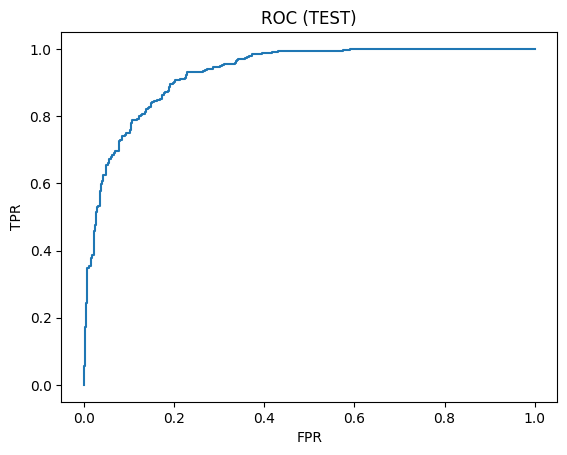

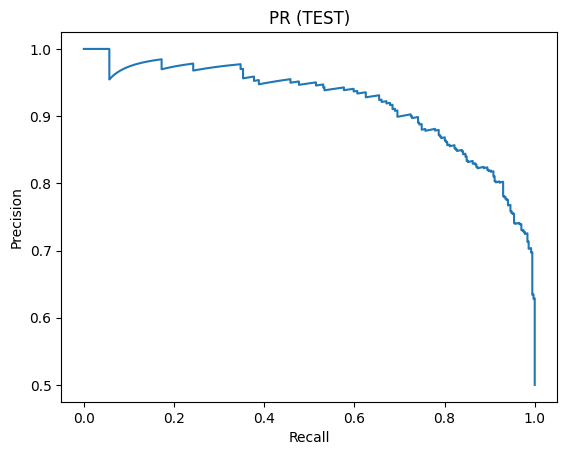

              precision    recall  f1-score   support

           0      0.880     0.809     0.843       371
           1      0.823     0.889     0.855       371

    accuracy                          0.849       742
   macro avg      0.851     0.849     0.849       742
weighted avg      0.851     0.849     0.849       742

confusion_matrix [[tn, fp],[fn, tp]]: [[300, 71], [41, 330]]

VK subset:
              precision    recall  f1-score   support

           0      0.888     0.869     0.878       237
           1      0.869     0.888     0.878       232

    accuracy                          0.878       469
   macro avg      0.879     0.879     0.878       469
weighted avg      0.879     0.878     0.878       469

ROC-AUC: 0.95029463116543  PR-AUC: 0.9381216119169248

TG subset:
              precision    recall  f1-score   support

           0      0.862     0.701     0.774       134
           1      0.756     0.892     0.818       139

    accuracy                          0.799

In [116]:
from sklearn.metrics import roc_curve, precision_recall_curve, classification_report, confusion_matrix

# Глобальные кривые
fpr, tpr, _ = roc_curve(y_test, proba)
prec, rec, _ = precision_recall_curve(y_test, proba)

import matplotlib.pyplot as plt
plt.figure(); plt.plot(fpr, tpr); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC (TEST)"); plt.show()
plt.figure(); plt.plot(rec, prec); plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("PR (TEST)"); plt.show()

# Метрики с фиксированным порогом
yhat = (proba >= thr_test).astype(int)
print(classification_report(y_test, yhat, digits=3))
print("confusion_matrix [[tn, fp],[fn, tp]]:", confusion_matrix(y_test, yhat).tolist())

# Разбивка VK vs TG на тесте
plat_test = df.loc[X_test_idx, "platform"].astype(str).str.lower().values
vk_mask = np.array([p.startswith("vk") for p in plat_test])
tg_mask = np.array([p.startswith("tg") or p.startswith("tele") for p in plat_test])

for name, m in [("VK", vk_mask), ("TG", tg_mask)]:
    if m.any():
        print(f"\n{name} subset:")
        print(classification_report(y_test[m], yhat[m], digits=3))
        print("ROC-AUC:", roc_auc_score(y_test[m], proba[m]), 
              " PR-AUC:", average_precision_score(y_test[m], proba[m]))


SHAP summary (global feature importance & effect) + PDP(PDP — Partial Dependence (1D)) + VK/TG(conditioned PDP)


We prioritized interpretable features from the Top-40 (gain) to produce SHAP and PDP charts that stakeholders can reason about (length, links, hashtags, emojis, mentions, sentiment, domain lexicons). Embedding dimensions also rank highly; however, individual SBERT/CLIP coordinates are not semantically meaningful. We therefore report their group-level SHAP (SBERT vs CLIP) and, for completeness, list the top few coordinates by |SHAP| without PDP interpretation.

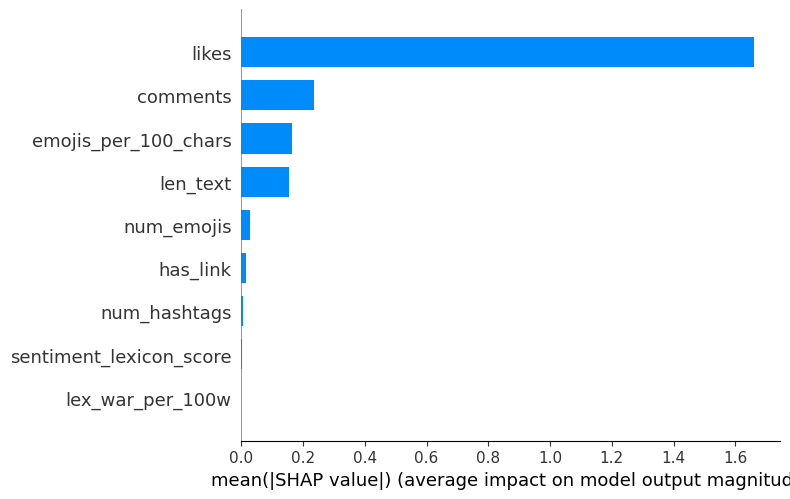

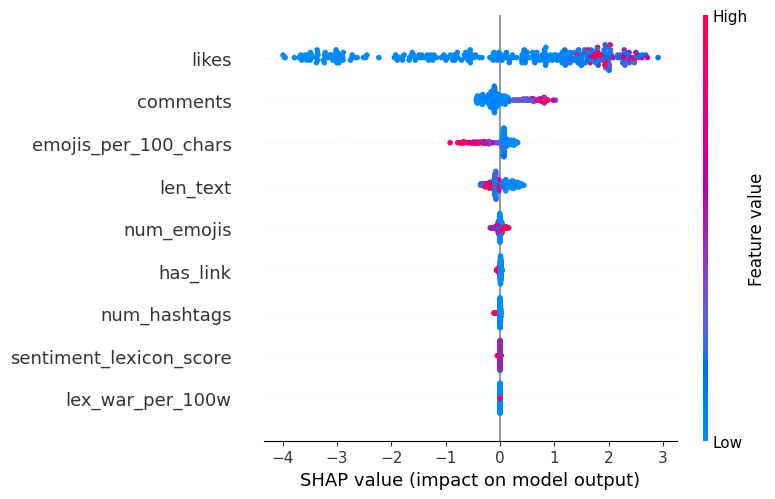

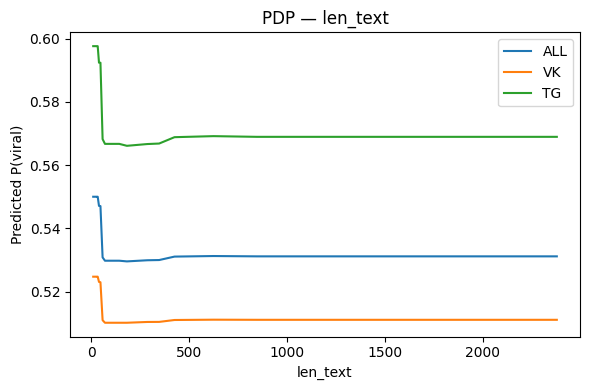

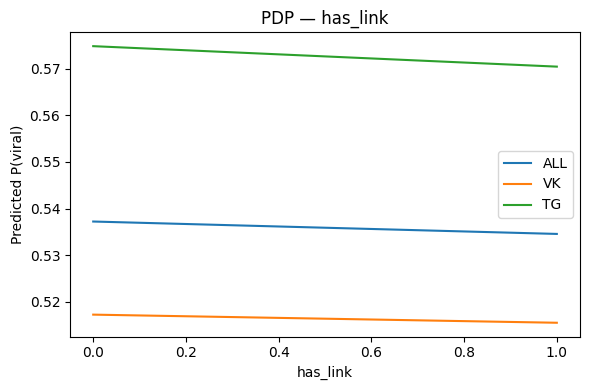

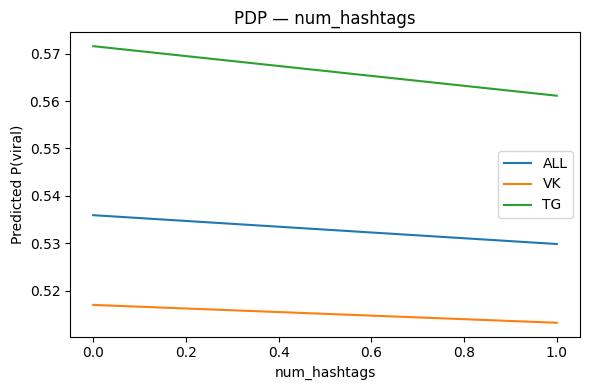

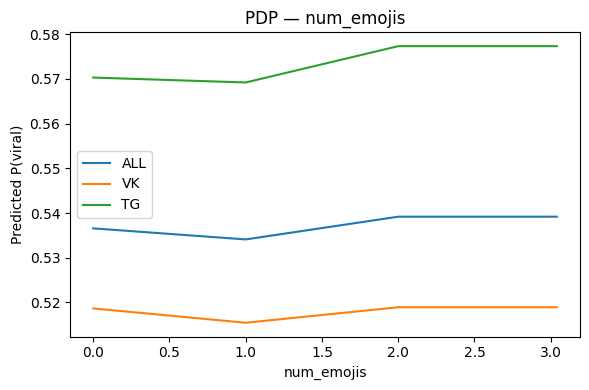

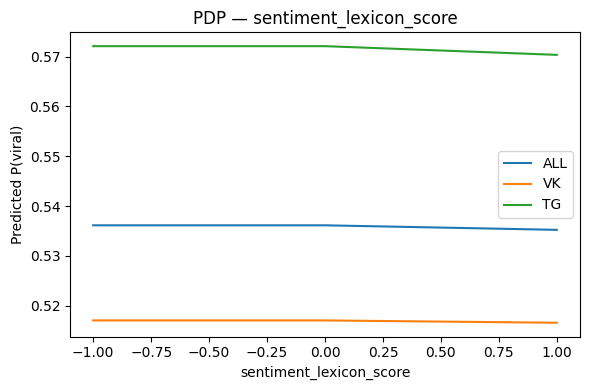

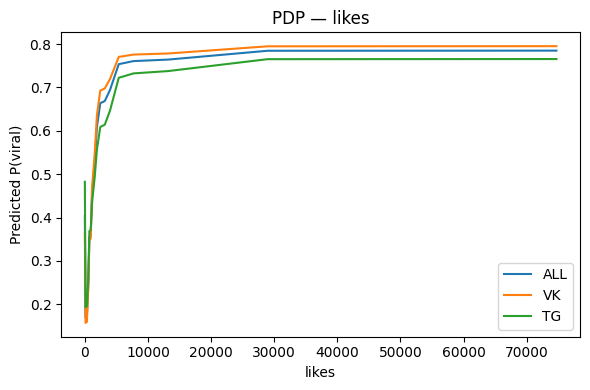

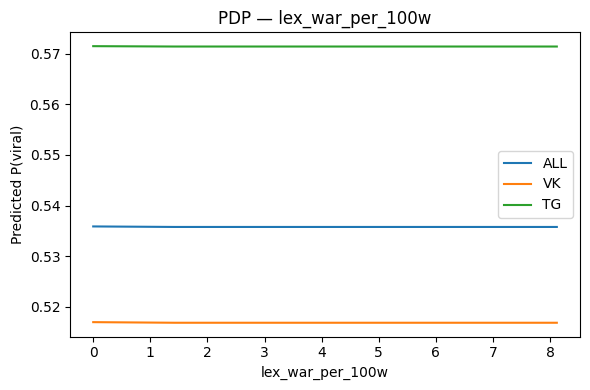

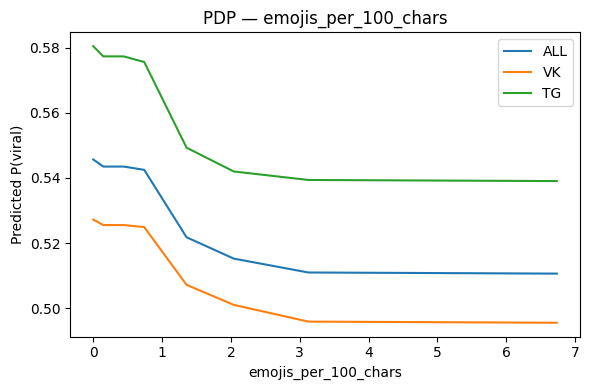

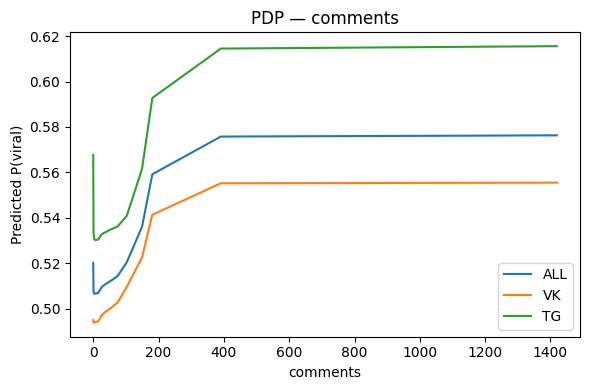

In [95]:
# === 0) Deps & helpers ===
import sys, importlib, numpy as np, pandas as pd, xgboost as xgb
def ensure(p):
    try:
        return importlib.import_module(p)
    except Exception:
        import subprocess; subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])
        importlib.invalidate_caches()
        return importlib.import_module(p)

shap = ensure("shap")
import matplotlib.pyplot as plt

# Confirm we have: booster or xgb_fusion.get_booster(), feature_names, X_val, y_val
try:
    booster
except NameError:
    booster = xgb_fusion.get_booster()
# Make sure feature names are set on booster
if not getattr(booster, "feature_names", None):
    booster.feature_names = feature_names

# Predict function using Booster (works for both train/sklearn APIs)
def predict_proba(X):
    dm = xgb.DMatrix(X, feature_names=feature_names)
    return booster.predict(dm)

# Map from feature name to index
feat2idx = {f:i for i,f in enumerate(feature_names)}

# === 1) SHAP summary & beeswarm for selected top features ===
top_feats = [
    "len_text", "has_link",  "num_hashtags",
    "num_emojis", "sentiment_lexicon_score","likes","lex_war_per_100w","emojis_per_100_chars", "comments"
]

# Ensure all are present (skip missing silently)
top_feats = [f for f in top_feats if f in feat2idx]
if not top_feats:
    raise ValueError("None of the selected top features found in feature_names.")

# Compute SHAP
explainer = shap.TreeExplainer(booster)
# SHAP может быть тяжёлым: при больших X_val можно взять сэмпл
n_sample = min(2000, X_val.shape[0])
rng = np.random.default_rng(42)
val_sel = rng.choice(X_val.shape[0], size=n_sample, replace=False)
Xv = X_val[val_sel]

shap_values = explainer.shap_values(xgb.DMatrix(Xv, feature_names=feature_names))
# shap_values shape: (n_sample, n_features)

# SHAP summary (bar) — глобальная важность только по выбранным фичам
sel_idx = [feat2idx[f] for f in top_feats]
shap.summary_plot(shap_values[:, sel_idx], Xv[:, sel_idx], feature_names=top_feats, plot_type="bar", show=True)

# SHAP beeswarm — знак и распределение
shap.summary_plot(shap_values[:, sel_idx], Xv[:, sel_idx], feature_names=top_feats, show=True)

# === 2) 1D PDP (custom; model-agnostic, with VK/TG split) ===

# Recover platform on validation set
# val_idx are indices inside the training set; map them to original df rows
train_orig_idx = np.array(X_train_idx)
val_orig_idx = train_orig_idx[val_idx][val_sel]
platform_val = df.loc[val_orig_idx, "platform"].astype(str).str.lower().values
vk_mask = np.array([p.startswith("vk") for p in platform_val])
tg_mask = np.array([p.startswith("tg") or p.startswith("tele") for p in platform_val])

def pdp_1d(feature_name, grid=None, n_grid=20):
    j = feat2idx[feature_name]
    x = Xv[:, j]
    # Build grid
    if grid is None:
        if np.unique(x).size <= 5:  # binary / small support
            grid = np.sort(np.unique(x))
        else:
            qs = np.linspace(0.01, 0.99, n_grid)
            grid = np.unique(np.quantile(x, qs))
    preds_all, preds_vk, preds_tg = [], [], []
    for g in grid:
        Xtmp = Xv.copy()
        Xtmp[:, j] = g
        p = predict_proba(Xtmp)  # proba for class=1
        preds_all.append(p.mean())
        if vk_mask.any():
            preds_vk.append(p[vk_mask].mean())
        else:
            preds_vk.append(np.nan)
        if tg_mask.any():
            preds_tg.append(p[tg_mask].mean())
        else:
            preds_tg.append(np.nan)
    return np.array(grid), np.array(preds_all), np.array(preds_vk), np.array(preds_tg)

def plot_pdp(feature_name):
    grid, y_all, y_vk, y_tg = pdp_1d(feature_name)
    plt.figure(figsize=(6,4))
    plt.plot(grid, y_all, label="ALL")
    if np.isfinite(y_vk).any(): plt.plot(grid, y_vk, label="VK")
    if np.isfinite(y_tg).any(): plt.plot(grid, y_tg, label="TG")
    plt.title(f"PDP — {feature_name}")
    plt.xlabel(feature_name)
    plt.ylabel("Predicted P(viral)")
    plt.legend()
    plt.tight_layout()
    plt.show()

for f in top_feats:
    plot_pdp(f)


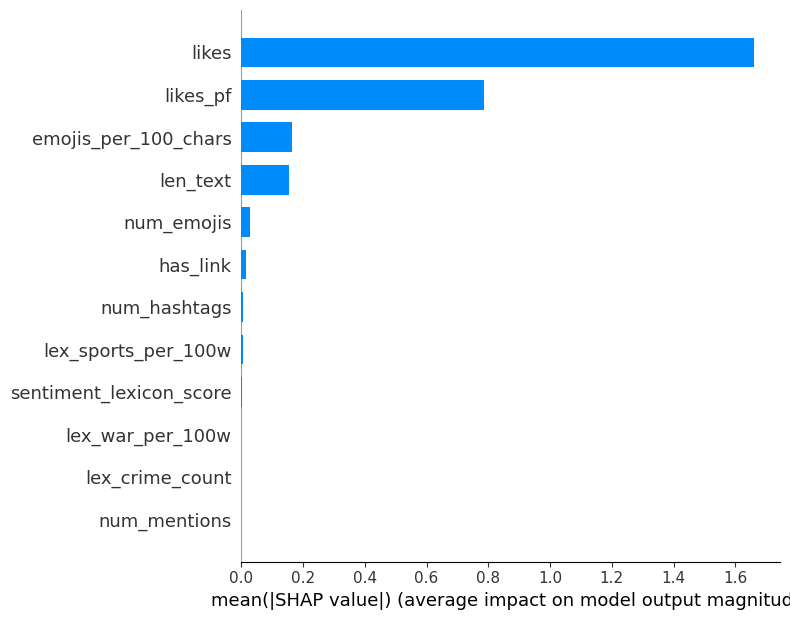

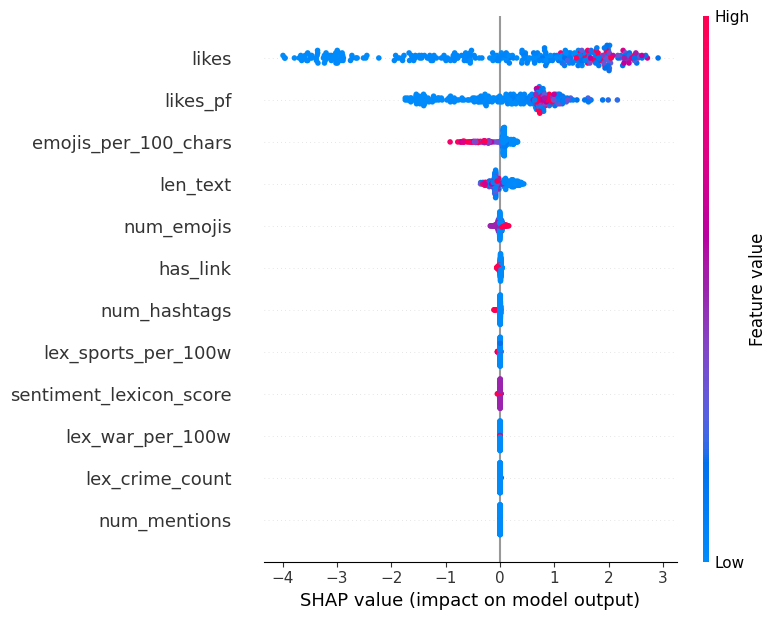

Group SHAP (avg |SHAP|): {'SBERT (avg |SHAP|)': 0.008646426722407341, 'CLIP (avg |SHAP|)': 0.0031831737142056227, 'TAB/meta (avg |SHAP|)': 0.05533352866768837}


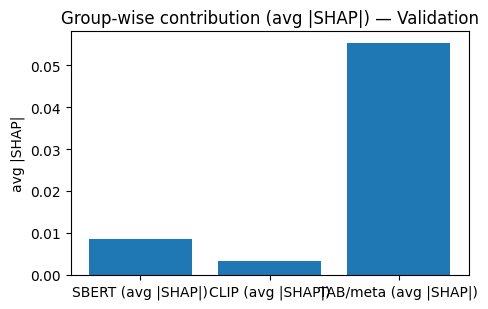

Top SBERT dims by |SHAP|: ['sbert_836', 'sbert_27', 'sbert_241', 'sbert_268', 'sbert_912']
Top CLIP  dims by |SHAP|: ['clip_emb_211', 'clip_emb_377', 'clip_emb_364', 'clip_emb_321', 'clip_emb_313']


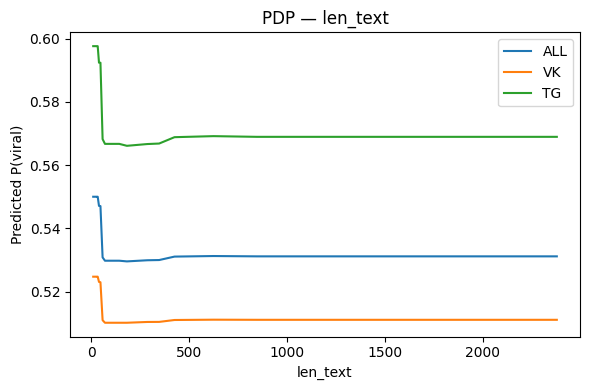

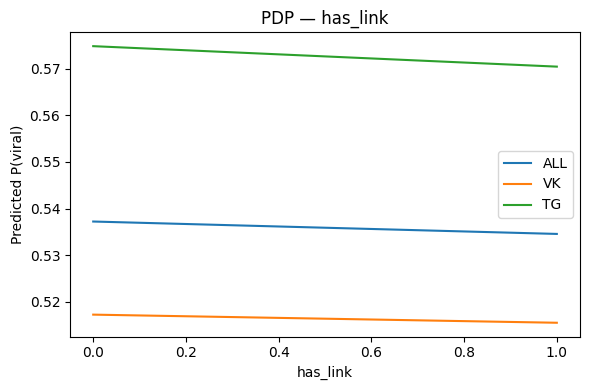

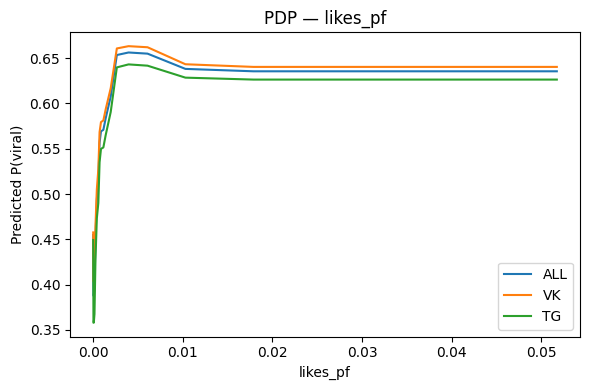

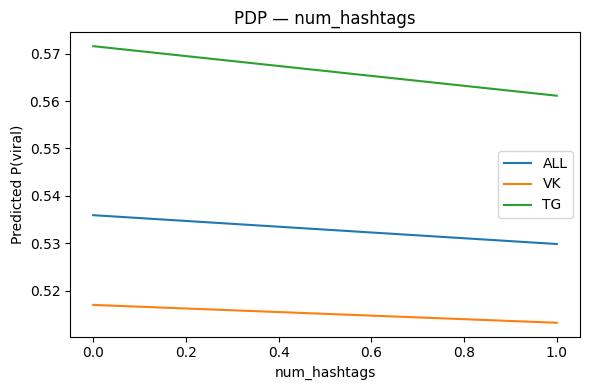

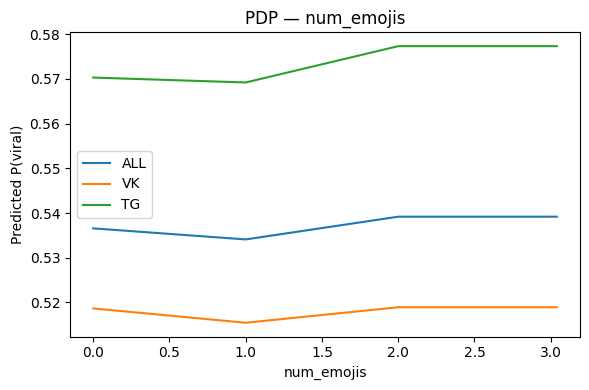

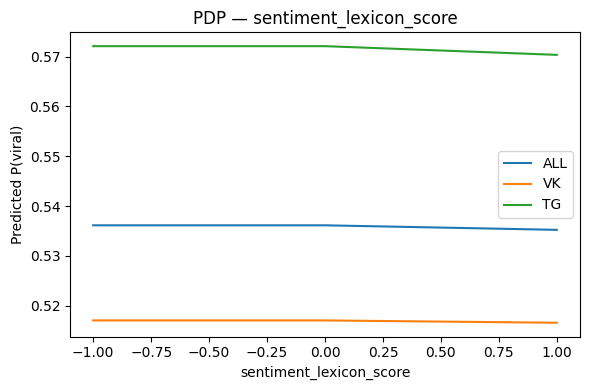

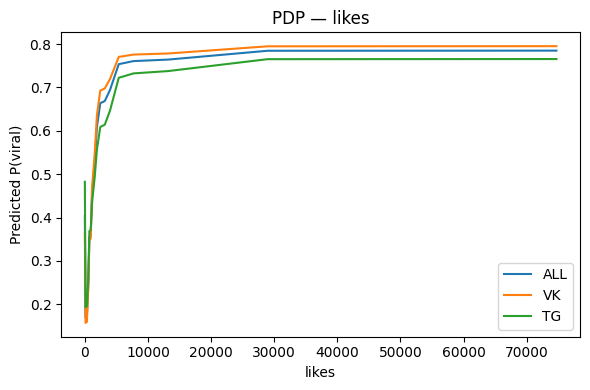

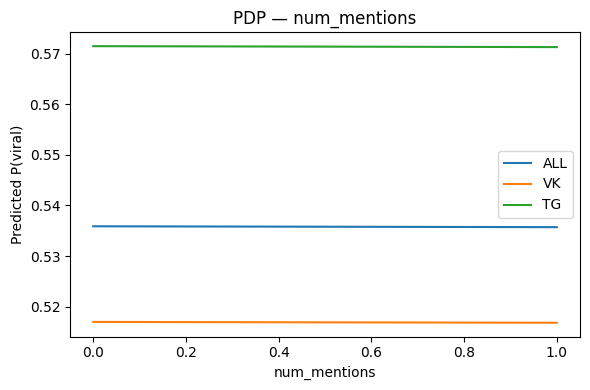

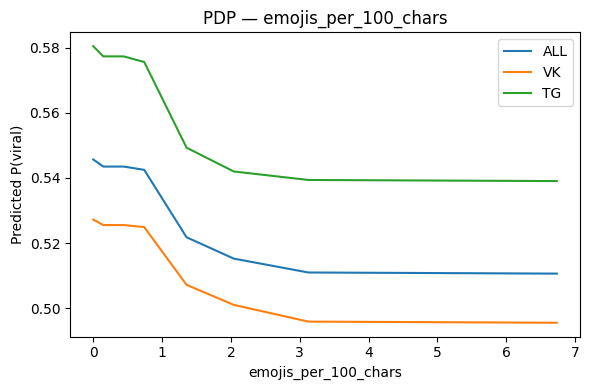

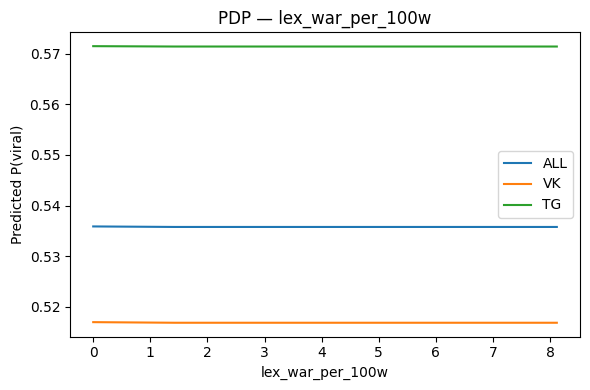

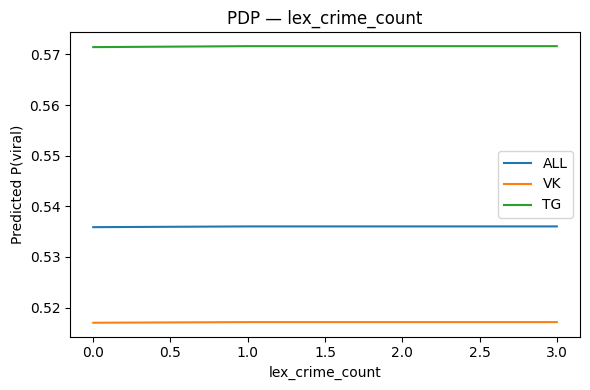

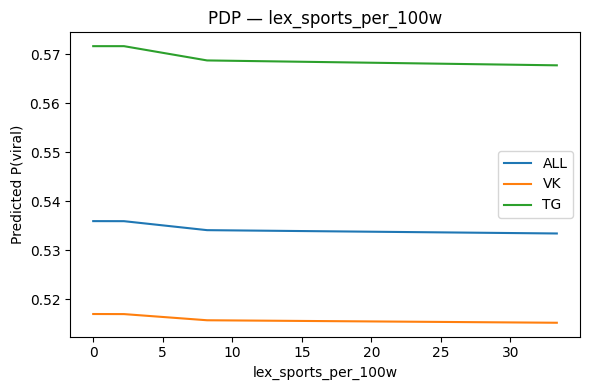

In [88]:
# === 0) Deps & helpers ===
import sys, importlib, numpy as np, pandas as pd, xgboost as xgb
def ensure(p):
    try:
        return importlib.import_module(p)
    except Exception:
        import subprocess; subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])
        importlib.invalidate_caches()
        return importlib.import_module(p)

shap = ensure("shap")
import matplotlib.pyplot as plt

# Confirm we have: booster or xgb_fusion.get_booster(), feature_names, X_val, y_val
try:
    booster
except NameError:
    booster = xgb_fusion.get_booster()
# Make sure feature names are set on booster
if not getattr(booster, "feature_names", None):
    booster.feature_names = feature_names

# Predict function using Booster (works for both train/sklearn APIs)
def predict_proba(X):
    dm = xgb.DMatrix(X, feature_names=feature_names)
    return booster.predict(dm)

# Map from feature name to index
feat2idx = {f:i for i,f in enumerate(feature_names)}

# === 1) SHAP summary & beeswarm for selected top META features ===
# базовые мета-фичи
top_feats = [
    "len_text", "has_link", "likes_pf", "num_hashtags",
    "num_emojis", "sentiment_lexicon_score"
]
# добавляем другие из твоего Top-40 (если есть в данных)
extra_meta_candidates = [
    "likes", "num_mentions", "emojis_per_100_chars",
    "lex_war_per_100w", "lex_crime_count", "lex_sports_per_100w"
]
extra_meta = [f for f in extra_meta_candidates if f in feat2idx and f not in top_feats]
top_feats_all = [f for f in (top_feats + extra_meta) if f in feat2idx]  # защита и дедуп

if not top_feats_all:
    raise ValueError("None of the selected top META features found in feature_names.")

# Compute SHAP
explainer = shap.TreeExplainer(booster)
# SHAP может быть тяжёлым: при больших X_val берём сэмпл
n_sample = min(2000, X_val.shape[0])
rng = np.random.default_rng(42)
val_sel = rng.choice(X_val.shape[0], size=n_sample, replace=False)
Xv = X_val[val_sel]

# В твоей версии SHAP вычислялся на DMatrix — оставляю так же для совместимости
shap_values = explainer.shap_values(xgb.DMatrix(Xv, feature_names=feature_names))
# shap_values shape: (n_sample, n_features)

# SHAP summary (bar) — глобальная важность только по выбранным мета-фичам
sel_idx = [feat2idx[f] for f in top_feats_all]
shap.summary_plot(shap_values[:, sel_idx], Xv[:, sel_idx],
                  feature_names=top_feats_all, plot_type="bar", show=True)

# SHAP beeswarm — знак и распределение
shap.summary_plot(shap_values[:, sel_idx], Xv[:, sel_idx],
                  feature_names=top_feats_all, show=True)

# === 1b) SBERT & CLIP — групповой вклад и топ-координаты ===
idx_sbert = np.array([i for i,f in enumerate(feature_names) if f.startswith("sbert_")])
idx_clip  = np.array([i for i,f in enumerate(feature_names) if f.startswith("clip_emb_")])
idx_tab   = np.array([i for i in range(len(feature_names)) if i not in set(idx_sbert)|set(idx_clip)])

abs_shap = np.abs(shap_values)
grp = {
    "SBERT (avg |SHAP|)": float(abs_shap[:, idx_sbert].mean()) if idx_sbert.size else 0.0,
    "CLIP (avg |SHAP|)":  float(abs_shap[:, idx_clip].mean())  if idx_clip.size  else 0.0,
    "TAB/meta (avg |SHAP|)": float(abs_shap[:, idx_tab].mean()) if idx_tab.size  else 0.0,
}
print("Group SHAP (avg |SHAP|):", grp)

# Быстрый барплот групп
plt.figure(figsize=(5,3.2))
plt.bar(list(grp.keys()), list(grp.values()))
plt.title("Group-wise contribution (avg |SHAP|) — Validation")
plt.ylabel("avg |SHAP|")
plt.tight_layout()
plt.show()

# Топ координаты у SBERT/CLIP по |SHAP| (иллюстративно)
def top_dims(idx, k=5):
    if idx.size == 0: return []
    col_abs = abs_shap[:, idx].mean(axis=0)
    order = np.argsort(-col_abs)[:k]
    return [feature_names[idx[o]] for o in order]

print("Top SBERT dims by |SHAP|:", top_dims(idx_sbert, k=5))
print("Top CLIP  dims by |SHAP|:", top_dims(idx_clip,  k=5))

# === 2) 1D PDP (custom; model-agnostic, with VK/TG split) ===

# Recover platform on validation set
# val_idx are indices inside the training set; map them to original df rows
train_orig_idx = np.array(X_train_idx)
val_orig_idx = train_orig_idx[val_idx][val_sel]
platform_val = df.loc[val_orig_idx, "platform"].astype(str).str.lower().values
vk_mask = np.array([p.startswith("vk") for p in platform_val])
tg_mask = np.array([p.startswith("tg") or p.startswith("tele") for p in platform_val])

def pdp_1d(feature_name, grid=None, n_grid=20):
    j = feat2idx[feature_name]
    x = Xv[:, j]
    # Build grid
    if grid is None:
        if np.unique(x).size <= 5:  # binary / small support
            grid = np.sort(np.unique(x))
        else:
            qs = np.linspace(0.01, 0.99, n_grid)
            grid = np.unique(np.quantile(x, qs))
    preds_all, preds_vk, preds_tg = [], [], []
    for g in grid:
        Xtmp = Xv.copy()
        Xtmp[:, j] = g
        p = predict_proba(Xtmp)  # proba for class=1
        preds_all.append(p.mean())
        if vk_mask.any():
            preds_vk.append(p[vk_mask].mean())
        else:
            preds_vk.append(np.nan)
        if tg_mask.any():
            preds_tg.append(p[tg_mask].mean())
        else:
            preds_tg.append(np.nan)
    return np.array(grid), np.array(preds_all), np.array(preds_vk), np.array(preds_tg)

def plot_pdp(feature_name):
    grid, y_all, y_vk, y_tg = pdp_1d(feature_name)
    plt.figure(figsize=(6,4))
    plt.plot(grid, y_all, label="ALL")
    if np.isfinite(y_vk).any(): plt.plot(grid, y_vk, label="VK")
    if np.isfinite(y_tg).any(): plt.plot(grid, y_tg, label="TG")
    plt.title(f"PDP — {feature_name}")
    plt.xlabel(feature_name)
    plt.ylabel("Predicted P(viral)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Строим PDP по расширенному списку мета-фич
for f in top_feats_all:
    plot_pdp(f)
